<a href="https://colab.research.google.com/github/FRIDA-34/EstadisticaVerano2026/blob/main/proyectointegrador/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df= pd.read_csv("https://raw.githubusercontent.com/FRIDA-34/EstadisticaVerano2026/refs/heads/main/proyectointegrador/C%C3%93DIGOFINAL%20(1).csv")

df

,Genero,Edad,Semestre,Carrera,Horas_de_clase_al_dia,Horas_de_estudio_fuera_de_clase,Frecuencias_de_tareas_proyectos,Trabajas_ademas_de_estudiar,Actividad_fisica,Horas_de_redes_sociales,Dispositivos_antes_de_dormir,Hora_de_dormir,Hora_de_despertar,Horas_de_sueño,Descansas_al_despertar,Dificultad_para_dormir,Calidad_del_sueño,Factor_que_mas_influye_en_tu_descanso
0,Hombre,20,5,ige,4,4,Siempre,Medio tiempo,3,3,3,9,7,7.5,Casi siempre,Rara vez,4,Carga academica
1,Hombre,21,7,ige,5,2,Algunas veces,Medio tiempo,4,4,5,10,5,5.0,Rara vez,Algunas veces,3,Estres
2,Mujer,19,5,ige,4,1,Frecuentemente,No,4,5,2,11,6,5.5,Rara vez,Algunas veces,3,Carga academica
3,Mujer,23,6,ige,5,3,Rara vez,Medio tiempo,2,3,5,2,8,6.4,Rara vez,Rara vez,4,Estres
4,Mujer,20,5,tics,7,2,Frecuentemente,Medio tiempo,1,6,3,1,8,5.3,Casi siempre,Rara vez,3,Trabajo
5,Hombre,21,8,ige,4,2,Frecuentemente,Medio tiempo,3,3,4,11,6,5.0,Casi siempre,Rara vez,4,Trabajo
6,Hombre,20,5,tics,5,1,Algunas veces,Ocasionalmente,5,5,2,12,5,5.5,Siempre,Nunca,4,Otro
7,Hombre,24,4,industrial,8,1,Algunas veces,Medio tiempo,2,4,5,10,7,5.3,Rara vez,Frecuentemente,3,Trabajo
8,Hombre,21,6,tics,5,2,Algunas veces,Medio tiempo,4,2,4,9,7,6.0,Casi siempre,Frecuentemente,3,Celular
9,Hombre,20,5,electrica,6,1,Frecuentemente,Medio tiempo,2,3,3,2,5,4.5,Rara vez,Frecuentemente,4,Estres


Se recopiló informacion de los estudiantes del Instituto Tecnologico de Aguascalientes, de diferentes carreras por medio de una encuesta y se analizaron como afectan sus "horas de sueño", dependiendo su carrera y genero, si es por su carrera, serian IGE, Industrial, LA, Electrica y Tics, y a su genero seria hombre y mujer, con esto queremos saber que carrera afecta mas las horas de sueño

| IGE | LA  | TICS  | IND  | ELEC  |
|-----|----|----|----|----|
|  7.5  | 7.0 | 5.3  | 5.3 | 4.5 |
|  5.0  | 8.0  | 5.5  | 6.5 | 5.5 |
|  5.5  | 6.3  | 6.0 | 8.0 | 6.0 |
|  6.4  | 8.0  | 5.5  | 7.5 | 6.5  |
|  5.5  | 5.6  | 5.5  | 7.5 | 4.5  |


In [ ]:
import pandas as pd
from io import StringIO

datos='''
Carrera,Horas_de_sueño
IGE, 7.5
LA, 7.0
TICS, 5.3
IND, 5.3
ELEC, 4.5
IGE, 5.0
LA, 8.0
TICS, 5.5
IND, 6.5
ELEC, 5.5
IGE, 5.5
LA, 6.3
TICS, 6.0
IND, 8.0
ELEC, 6.0
IGE, 6.4
LA, 8.0
TICS, 5.5
IND, 7.5
ELEC, 6.5
IGE, 5.5
LA, 5.6
TICS, 5.5
IND, 7.5
ELEC, 4.5
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,Carrera,Horas_de_sueño
0,IGE,7.5
1,LA,7.0
2,TICS,5.3
3,IND,5.3
4,ELEC,4.5
5,IGE,5.0
6,LA,8.0
7,TICS,5.5
8,IND,6.5
9,ELEC,5.5


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3
#H1: al menos una media es diferente

modelo = ols('Horas_de_sueño~ C(Carrera)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Carrera),11.4056,4.0,3.4646,0.0263
Residual,16.4600,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.8460421953705985


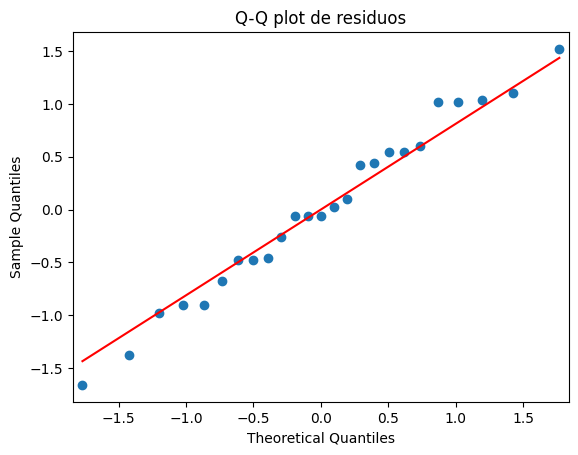

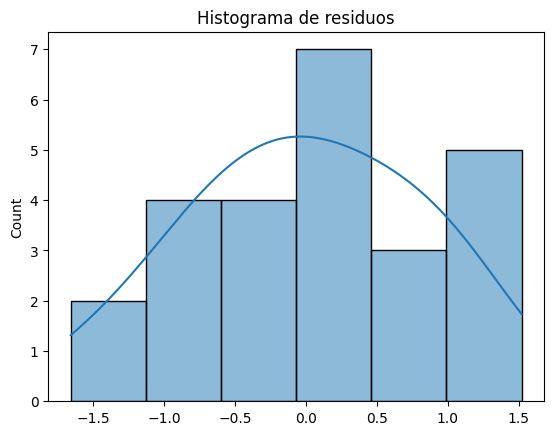

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Carrera'] == 'IGE']['Horas_de_sueño']
grupo_B = df[df['Carrera'] == 'LA']['Horas_de_sueño']
grupo_C = df[df['Carrera'] == 'TICS']['Horas_de_sueño']
grupo_D = df[df['Carrera'] == 'IND']['Horas_de_sueño']
grupo_E = df[df['Carrera'] == 'ELEC']['Horas_de_sueño']


stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.9206
p-valor: 0.1890


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  ELEC    IGE     0.58 0.8474 -1.1369 2.2969  False
  ELEC    IND     1.56 0.0863 -0.1569 3.2769  False
  ELEC     LA     1.58 0.0806 -0.1369 3.2969  False
  ELEC   TICS     0.16 0.9986 -1.5569 1.8769  False
   IGE    IND     0.98 0.4516 -0.7369 2.6969  False
   IGE     LA      1.0  0.432 -0.7169 2.7169  False
   IGE   TICS    -0.42 0.9464 -2.1369 1.2969  False
   IND     LA     0.02    1.0 -1.6969 1.7369  False
   IND   TICS     -1.4 0.1454 -3.1169 0.3169  False
    LA   TICS    -1.42 0.1365 -3.1369 0.2969  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

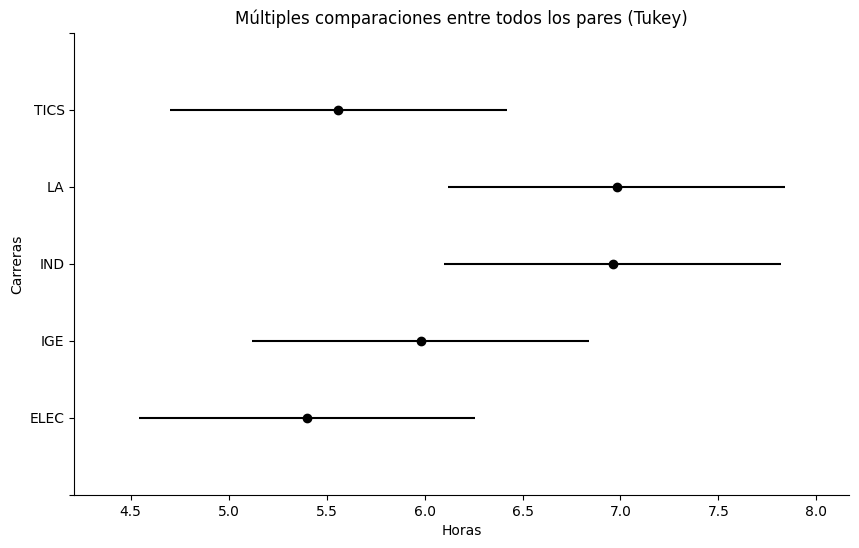

In [ ]:
#WILLIAMS ABRAHAM FLORIANO LARA
#Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Horas_de_sueño'], # Variable de respuesta
    groups=df['Carrera'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Carreras", xlabel="Horas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
#WILLIAMS ABRAHAM FLORIANO LARA
# Calcular promedios de cada método

df.groupby(["Carrera"]).mean()["Horas_de_sueño"]

,Horas_de_sueño
Carrera,
ELEC,5.40
IGE,5.98
IND,6.96
LA,6.98
TICS,5.56


In [ ]:
#WILLIAMS ABRAHAM FLORIANO LARA
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Carrera)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.409


In [ ]:
#WILLIAMS ABRAHAM FLORIANO LARA
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Carrera"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.4093
f de Cohen = 0.8324
Potencia de la prueba = 0.8575


Conclusion. El diseño experimental se realizó para analizar si existen diferencias en las horas de sueño entre estudiantes de distintas carreras universitarias. Antes de aplicar el modelo, se verificaron los supuestos mediante las pruebas de normalidad de Shapiro-Wilk (p = 0.8460) y homogeneidad de varianzas de Levene (p = 0.1890), cuyos resultados indican que los datos cumplen con los requisitos necesarios para realizar un ANOVA. De acuerdo con el análisis de varianza (ANOVA), se obtuvo un valor de p = 0.0263, por lo que, utilizando un nivel de significancia del 5%, sí existe evidencia estadísticamente significativa para afirmar que las horas de sueño difieren entre al menos algunas de las carreras analizadas (IGE, LA, TICS, Industrial y Eléctrica).

Sin embargo, al realizar la prueba de comparaciones múltiples de Tukey, no se identificó ningún par de carreras con diferencias estadísticamente significativas (todas las comparaciones presentaron p > 0.05). Aunque las comparaciones entre Eléctrica con Industrial y Eléctrica con LA fueron las más cercanas al nivel de significancia, no alcanzaron el criterio necesario para considerarlas diferentes. Esto sugiere que la diferencia detectada por el ANOVA corresponde al comportamiento general de los grupos y no puede atribuirse con certeza a un par específico de carreras.

El tamaño del efecto obtenido fue η² = 0.409, lo que indica que aproximadamente el 40.9% de la variación observada en las horas de sueño puede explicarse por la carrera que cursan los estudiantes, representando un efecto grande. Además, la potencia estadística de la prueba fue de 0.8575 (85.75%), superando el 80% recomendado para detectar diferencias con buena confiabilidad. En conjunto, estos resultados permiten concluir que la carrera universitaria tiene una influencia importante sobre las horas de sueño de los estudiantes; sin embargo, sería recomendable aumentar el tamaño de la muestra para cada carrera con el fin de identificar con mayor precisión cuáles grupos presentan realmente las diferencias observadas